<a href="https://colab.research.google.com/github/ChungyiBossi/2026_gjun_summer/blob/main/%E5%95%86%E6%A5%AD%E8%B3%87%E6%96%99%E5%88%86%E6%9E%90.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 0.Overview
你剛加入一間台灣中型電商平台擔任**資料分析師**，公司在下一季設定了三個核心營運目標：

1. **提升營收（Revenue）**：目標較上季成長 8%。
2. **提升轉換率（Conversion Rate, CVR）**：讓更多訪客完成購買。
3. **控制風險**：退款率不可以上升，行銷成本維持在可控範圍。

你的任務是從現有資料中找出可行的成長策略，讓數據說話用來支撐決策，最終交付一份完整的分析報告與商業建議。這份報告必須能讓非技術背景的主管看懂、讓工程團隊能夠執行，且結論可供驗證。

> **為什麼選電商專案？**
> 電商資料結構涵蓋顧客、交易、行為、實驗四大面向，幾乎所有商業分析場景都能在其中練習。無論你未來進入金融、零售、SaaS 或媒體產業，本課程中所學的分析框架與技術都是很實用的。



| 表名          | 檔案                 | 筆數（約） | 粒度            | 說明               |
| ------------- | -------------------- | ---------- | --------------- | ------------------ |
| 顧客主檔      | `customers.csv`      | 2,500      | 一列 = 一位顧客 | 顧客基本屬性       |
| 產品主檔      | `products.csv`       | 60         | 一列 = 一個產品 | 6 大類各 10個 品項 |
| 訂單主檔      | `orders.csv`         | 22,000     | 一列 = 一筆訂單 | 訂單層級資訊       |
| 訂單明細      | `order_items.csv`    | ~39,000    | 一列 = 一筆品項 | 品項層級金額       |
| 工作階段      | `sessions.csv`       | 70,000     | 一列 = 一次造訪 | 使用者瀏覽行為     |
| 事件流        | `events.csv`         | ~200,000   | 一列 = 一個事件 | 頁面瀏覽/加購/購買 |
| A/B 分組      | `ab_assignments.csv` | 2,500      | 一列 = 一位顧客 | 實驗分組紀錄       |
| SQLite 資料庫 | `course.db`          | —          | 含上述所有表    | 供 SQL 堂課使用    |

## 0-1. Customer Data

| 欄位                  | 型別 | 說明                   | 範例                                                  |
| --------------------- | ---- | ---------------------- | ----------------------------------------------------- |
| `customer_id`         | int  | 顧客唯一識別碼（主鍵） | 1, 2, 3                                               |
| `signup_date`         | date | 註冊日期               | 2023-08-15                                            |
| `acquisition_channel` | str  | 獲客管道               | organic, ads, referral, partner, social               |
| `city`                | str  | 所在城市               | Taipei, Taichung, Kaohsiung, Tainan, Hsinchu, Taoyuan |
| `segment`             | str  | 客群分級               | new（60%）, growth（30%）, vip（10%）   


1. **Organic（自然流量）**：指沒有透過付費廣告，自然進入網站的流量。通常包括使用者透過搜尋引擎（例如 Google、Bing）找到網站，網站因為搜尋引擎最佳化（SEO）做得好而獲得較高排名；也可能是**使用者直接輸入網址**進入網站的直接流量。
2. **Ads（廣告流量）**：指透過付費廣告活動所產生的流量。例如搜尋引擎行銷（SEM）、網路展示型廣告、社群媒體廣告，或其他形式的付費推廣。
3. **Referral（推薦／引薦流量）**：指來自其他網站連結的流量。舉例來說，部落格、新聞網站、商品評價平台，或其他外部網站放置連結，引導使用者進入你的電子商務平台。
4. **Partner（合作夥伴流量）**：通常指透過特定的策略合作夥伴或商業合作所取得的流量或客戶。它可以被視為Referral（推薦流量）的一種，但特別強調雙方具有正式的合作關係。
5. **Social（社群流量）**：指來自各種社群媒體平台的流量，例如 Facebook、Instagram、X（原 Twitter）、LinkedIn 等。使用者可能點擊社群平台上分享的連結，進而進入你的網站。

In [ ]:
customer_df = pd.read_csv('/content/drive/MyDrive/工作/2026/巨匠北認-商業資料分析/data/raw/customers.csv')

In [ ]:
display(customer_df.head()), len(customer_df)

,customer_id,signup_date,acquisition_channel,city,segment
0,1,2022-11-29,partner,Taipei,growth
1,2,2024-11-11,organic,Tainan,growth
2,3,2025-08-17,social,Hsinchu,vip
3,4,2025-06-09,organic,Taipei,growth
4,5,2024-07-23,referral,Taichung,new


(None, 2500)

## 0-2. Product Data

| 欄位         | 型別 | 說明                   | 範例                                                |
| ------------ | ---- | ---------------------- | --------------------------------------------------- |
| `product_id` | int  | 產品唯一識別碼（主鍵） | 1~60                                                |
| `category`   | str  | 產品類別               | electronics, home, beauty, grocery, sports, fashion |
| `unit_price` | int  | 定價（TWD）            | 100 ~ 5000                                          |


In [ ]:
product_df = pd.read_csv('/content/drive/MyDrive/工作/2026/巨匠北認-商業資料分析/data/raw/products.csv')

In [ ]:
display(product_df.head()), len(product_df)

,product_id,category,unit_price
0,1,electronics,150
1,2,electronics,3850
2,3,electronics,3713
3,4,electronics,2293
4,5,electronics,1760


(None, 60)

## 0-3. Orders Data
| 欄位           | 型別 | 說明                       | 範例                                               |
| -------------- | ---- | -------------------------- | -------------------------------------------------- |
| `order_id`     | int  | 訂單唯一識別碼（主鍵）     | 1~22000                                            |
| `customer_id`  | int  | 下單顧客（外鍵→customers） | 1250                                               |
| `order_date`   | date | 下單日期                   | 2025-03-14                                         |
| `status`       | str  | 訂單狀態                   | completed（93%）, cancelled（4%）, refunded（3%）  |
| `payment_type` | str  | 付款方式                   | card（50%）, atm（25%）, cod(Cash On Delivery)（10%）, wallet（15%） |

In [ ]:
order_df = pd.read_csv('/content/drive/MyDrive/工作/2026/巨匠北認-商業資料分析/data/raw/orders.csv')
display(order_df.head()), len(order_df)

,order_id,customer_id,order_date,status,payment_type
0,1,2323,2025-05-02,completed,wallet
1,2,117,2024-07-14,completed,wallet
2,3,160,2025-03-29,cancelled,card
3,4,1240,2024-07-08,completed,atm
4,5,714,2024-08-12,completed,atm


(None, 22000)

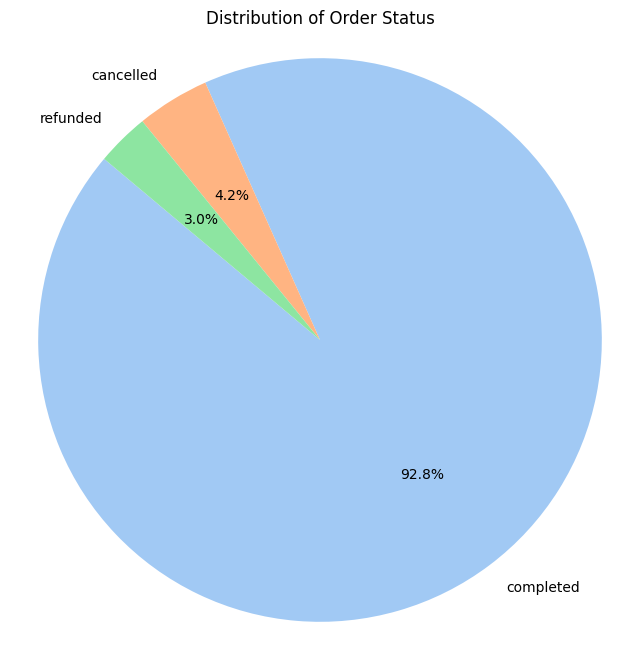

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the percentage of each order status
status_counts = order_df['status'].value_counts(normalize=True)

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('pastel')
)
plt.title('Distribution of Order Status')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

## 0-4. Order_item

| 欄位            | 型別  | 說明                      | 範例                             |
| --------------- | ----- | ------------------------- | -------------------------------- |
| `order_id`      | int   | 所屬訂單（外鍵→orders）   | 1050                             |
| `product_id`    | int   | 品項產品（外鍵→products） | 23                               |
| `quantity`      | int   | 購買數量                  | 1（80%）, 2（17%）, 3（3%）      |
| `unit_price`    | int   | 成交單價（TWD）           | 1299                             |
| `discount_rate` | float | 折扣率                    | 0（40%）, 0.05, 0.10, 0.15, 0.20 |


> **關鍵公式**：`line_revenue = quantity × unit_price × (1 - discount_rate)`

In [ ]:
order_item_df = pd.read_csv('/content/drive/MyDrive/工作/2026/巨匠北認-商業資料分析/data/raw/order_items.csv')
display(order_item_df.head()), len(order_item_df)

,order_id,product_id,quantity,unit_price,discount_rate
0,1,28,1,567,0.05
1,2,2,1,3850,0.05
2,2,18,1,778,0.10
3,3,19,1,2193,0.00
4,3,36,1,1580,0.15


(None, 39627)

## 0-5. Session 工作流

| 欄位               | 型別     | 說明                     | 範例值                                                 |
| ------------------ | -------- | ------------------------ | ------------------------------------------------------ |
| `session_id`       | int      | 造訪唯一識別碼（主鍵）   | 1~70000                                                |
| `customer_id`      | int      | 造訪者（外鍵→customers） | 800                                                    |
| `session_start`    | datetime | 造訪開始時間             | 2025-06-01T14:30                                       |
| `device`           | str      | 裝置類型                 | mobile（62%）, desktop（33%）, tablet（5%）            |
| `traffic_source`   | str      | 流量來源                 | seo, sem, direct, social, email                        |
| `campaign`         | str      | 活動標記                 | none（55%）, spring_sale, double11, new_user, retarget |
| `experiment_group` | str      | 實驗分組                 | A（50%）, B（50%）                                     |



In [ ]:
sessions_df = pd.read_csv('/content/drive/MyDrive/工作/2026/巨匠北認-商業資料分析/data/raw/sessions.csv')
display(sessions_df.head()), len(sessions_df)

,session_id,customer_id,session_start,device,traffic_source,campaign,experiment_group
0,1,2473,2025-08-14T11:02,desktop,sem,none,B
1,2,2155,2024-02-29T11:56,mobile,sem,retarget,A
2,3,2437,2024-11-13T16:23,mobile,sem,none,B
3,4,164,2024-04-22T16:15,mobile,email,retarget,B
4,5,1604,2024-06-15T08:39,desktop,direct,none,A


(None, 70000)

## 0-6. Event 事件流

| 欄位         | 型別     | 說明                         | 範例值                           |
| ------------ | -------- | ---------------------------- | -------------------------------- |
| `event_id`   | int      | 事件唯一識別碼（主鍵）       | 1~200000+                        |
| `session_id` | int      | 所屬造訪（外鍵→sessions）    | 35000                            |
| `event_type` | str      | 事件類型                     | page_view, add_to_cart, purchase |
| `event_time` | datetime | 事件發生時間                 | 2025-06-01T14:35                 |
| `order_id`   | int/空   | 對應訂單（僅 purchase 有值） | 8000                             |
| `revenue`    | float    | 對應營收（僅 purchase 有值） | 2580.50                          |


In [ ]:
events_df = pd.read_csv('/content/drive/MyDrive/工作/2026/巨匠北認-商業資料分析/data/raw/events.csv')
display(events_df.head()), len(events_df)

,event_id,session_id,event_type,event_time,order_id,revenue
0,1,1,page_view,2025-08-14T11:02,NaN,0.0
1,2,1,page_view,2025-08-14T11:07,NaN,0.0
2,3,2,page_view,2024-02-29T11:56,NaN,0.0
3,4,2,page_view,2024-02-29T12:01,NaN,0.0
4,5,2,page_view,2024-02-29T11:58,NaN,0.0


(None, 232067)

## 0-7. AB 分組
| 欄位               | 型別 | 說明                   | 範例值     |
| ------------------ | ---- | ---------------------- | ---------- |
| `customer_id`      | int  | 顧客（外鍵→customers） | 1250       |
| `experiment_group` | str  | 分組                   | A, B       |
| `assign_date`      | date | 分組日期               | 2024-01-05 |


In [ ]:
ab_df = pd.read_csv('/content/drive/MyDrive/工作/2026/巨匠北認-商業資料分析/data/raw/ab_assignments.csv')
display(ab_df.head()), len(ab_df)

,customer_id,experiment_group,assign_date
0,1,B,2024-01-11
1,2,B,2024-01-13
2,3,A,2024-01-10
3,4,A,2024-01-13
4,5,A,2024-01-09


(None, 2500)

## 0-8.小結

```
customers ─────────┬──────────── ab_assignments
  │(1)          │(1)              (1:1)
  ▼(N)          ▼(N)
orders           sessions
  │(1)          │(1)
  ▼(N)          ▼(N)
order_items        events
  │(N)
  │
  ▼(1)
products
```

- `customers` → `orders`：一對多（一位顧客可下多筆訂單）
- `orders` → `order_items`：一對多（一筆訂單可含多個品項）
- `order_items` → `products`：多對一（多個品項可指向同一產品）
- `customers` → `sessions`：一對多（一位顧客可有多次造訪）
- `sessions` → `events`：一對多（一次造訪可產生多個事件）
- `customers` → `ab_assignments`：一對一（每位顧客固定分到 A 或 B 組）



> **注意事項**：`orders` 和 `order_items` 的粒度不同。如果直接將訂單層級欄位（如 `payment_type`）join 到品項層級再做加總，會因一對多而重複計算。

# 1.理解商業問題

一個好的問題分析具備三個特性：
1. **可以量化**
2. **可以驗證**
3. **可以實行**

以下框架可以將模糊的商業目標轉化為明確的分析任務：

目標（Goal）→ 指標定義（KPI）→ 約束條件（Constraint）→ 假設（Hypothesis）→ 行動（Action）

```
┌─────────────────────────────────────────────────────┐
│  1. Business Goal  要改善什麼？                       
│     例：下季營收較上季成長 8%                         
│         ↓                               
│  2. KPI 如何衡量？                        
│     例：Revenue（營收）, CVR（Conversion Rate，轉換率）, AOV（Average Order Value，平均訂單價值）, Refund Rate（退款率）             
│         ↓                               
│  3. Constraint 不能犧牲什麼？                    
│     例：退款率不超過 3.5%、行銷 ROI（Return on Investment，投資報酬率） > 2.0            
│         ↓                               
│  4. Hypothesis 我們猜測什麼？                    
│     例：ads 管道的 CVR（Conversion Rate，轉換率）低於 organic（自然流量）的 CVR，差異超過 1%      
│         ↓                                
│  5. Action 最後要做什麼決策？                 
│     例：加碼有效管道、停投低效管道、上線新版結帳流程   
└─────────────────────────────────────────────────────┘
```

## 1-1.商業問題拆解範例

### 拆解範例一：「提升營收」
| 層級       | 原始版（不完整） | 改寫版（具體可執行）                                                        |
| ---------- | ---------------- | --------------------------------------------------------------------------- |
| Goal       | 提升營收         | 下季完成訂單營收較上季成長 8%                                               |
| KPI        | 營收             | Revenue = Σ(quantity × unit_price × (1-discount_rate))，僅計 completed 訂單 |
| Constraint | —                | 退款率 ≤ 3.5%，AOV 不低於上季水準                                           |
| Hypothesis | 廣告品質不好     | ads 管道 CVR 為 4.2%，低於 organic 的 5.8%，差異 > 1%                       |
| Action     | 做更多分析       | 若假設成立：重新分配 ads 預算至 organic/referral (自然搜尋/參照引流)                           |

### 拆解範例二：「優化結帳流程」

| 層級       | 內容                                                                                |
| ---------- | ----------------------------------------------------------------------------------- |
| Goal       | 本季結帳頁 Checkout CVR 從 62% 提升至 68%（+6 個百分點）                            |
| KPI        | Checkout CVR = 完成購買數 / 進入結帳頁的 session 數；目前基準值：桌機 71%、行動 58% |
| Constraint | 平均頁面載入時間不得增加，客訴數不可上升                                            |
| Hypothesis | 行動裝置結帳 CVR 低於桌機超過 13 個百分點，主因為結帳步驟過多                        |
| Action     | 若成立，優先優化行動版結帳 UI（減少步驟、加入快速支付）                             |


### 拆解範例三：「降低退款」

| 層級       | 內容                                                                    |
| ---------- | ----------------------------------------------------------------------- |
| Goal       | 退款率從 3.0% 降至 2.5%                                                 |
| KPI        | Refund Rate = refunded 訂單數 / 總訂單數                                |
| Constraint | 客訴處理時效不可因此拉長                                                |
| Hypothesis | beauty 類退款率（5.2%）顯著高於其他類別（2.1%），因為商品照片與實物色差 |
| Action     | 若成立，針對 beauty 類加強商品描述與圖片品質                            |

> **常見陷阱**：「提升營收」本身不是一個完整的分析題目。它缺少指標定義（營收如何計算？含不含退款？）、期間（跟什麼比？）、條件約束（可以犧牲什麼？不能犧牲什麼？）。


### 資料粒度的重要性

**粒度** 是指一張表(DataFrame)中「一列代表什麼」。搞錯粒度是初學者最常犯的錯誤。

- `orders` 的粒度是**一筆訂單**——每個 `order_id` 出現一次。
- `order_items` 的粒度是**一個品項**——同一個 `order_id` 可出現多次。
- `sessions` 的粒度是**一次造訪**——每個 `session_id` 出現一次。
- `events` 的粒度是**一個事件**——同一個 `session_id` 可出現多次。

**錯誤示範**：把 `orders` 和 `order_items` 直接 merge 後，對 `payment_type` 做 count，會得到「品項數」而非「訂單數」，因為一筆訂單有多個品項。


## 1-2.定義公式

本專案的核心 KPI 定義如下：

| KPI         | 計算公式                                                            | 資料來源             |
| ----------- | ------------------------------------------------------------------- | -------------------- |
| Revenue 營收| `Σ(quantity × unit_price × (1 - discount_rate))`，僅 completed 訂單 | order_items + orders |
| CVR 轉換率  | `有 purchase 事件的 session 數 / 總 session 數`                     | sessions + events    |
| AOV 平均訂單價值         | `Revenue / completed 訂單數`                                        | 同 Revenue           |
| Refund Rate  退貨率 | `refunded 訂單數 / 總訂單數`         

**任務 1**：定義本專案 KPI 計算式
- 寫出 Revenue、CVR、AOV、Refund Rate 的精確計算公式。
- 明確指出每個公式用到哪些表、哪些欄位。

**任務 2**：列出 3 個可驗證假設
- 每個假設必須包含：比較對象、比較指標、預期方向、判斷門檻。
- 範例格式：「`ads` 管道的 CVR（4.2%）低於 `organic`（5.8%），差異超過 1 個百分點。」

**任務 3**：定義成功門檻
- 主指標：CVR 提升 ≥ 1.2 個百分點。
- 護欄指標：退款率不超過 3.5%。


## 1-3.營收計算

### Pandas `merge` 命令解釋

Pandas 中的 `pd.merge()` 函數用於根據共同的欄位或索引來合併兩個 DataFrame，這類似於關係型資料庫中的 JOIN 操作。以下是其主要參數及其工作原理的詳細說明：

### `pd.merge(left, right, on=None, how='inner', ...)`

- **`left`**: 要合併的第一個 DataFrame。
- **`right`**: 要合併的第二個 DataFrame。
- **`on`**: (可選) 用於連接的列名或列名列表。這些列必須同時存在於 `left` 和 `right` DataFrame 中。如果未指定，`merge` 將使用列名的交集作為鍵。
- **`how`**: (可選) 指定要執行的合併類型。這定義了如何處理在另一個 DataFrame 中沒有匹配行的行。常見選項包括：
    - **`'inner'` (預設)**: 僅使用 `left` 和 `right` DataFrame 中都存在的鍵組合。這類似於 SQL 的 `INNER JOIN`。
    - **`'left'`**: 使用 `left` DataFrame 中的所有鍵，並與 `right` DataFrame 進行匹配。如果 `left` 中的鍵在 `right` 中沒有匹配項，則 `right` 的列中將顯示 `NaN`（或 `None`）。這類似於 SQL 的 `LEFT JOIN`。
    - **`'right'`**: 使用 `right` DataFrame 中的所有鍵，並與 `left` DataFrame 進行匹配。如果 `right` 中的鍵在 `left` 中沒有匹配項，則 `left` 的列中將顯示 `NaN`（或 `None`）。這類似於 SQL 的 `RIGHT JOIN`。
    - **`'outer'`**: 使用 `left` 或 `right` DataFrame 中所有觀察到的鍵組合。如果某個鍵在其中一個 DataFrame 中沒有找到，則其列中將顯示 `NaN`（或 `None`）。這類似於 SQL 的 `FULL OUTER JOIN`。


In [ ]:
order_df.head()

,order_id,customer_id,order_date,status,payment_type
0,1,2323,2025-05-02,completed,wallet
1,2,117,2024-07-14,completed,wallet
2,3,160,2025-03-29,cancelled,card
3,4,1240,2024-07-08,completed,atm
4,5,714,2024-08-12,completed,atm


In [ ]:
order_item_df.head(10)

,order_id,product_id,quantity,unit_price,discount_rate
0,1,28,1,567,0.05
1,2,2,1,3850,0.05
2,2,18,1,778,0.10
3,3,19,1,2193,0.00
4,3,36,1,1580,0.15
5,4,58,1,1326,0.10
6,5,46,1,3785,0.00
7,5,4,1,2293,0.00
8,5,33,2,4175,0.15
9,6,2,1,3850,0.05


In [ ]:
order_items_with_orders = pd.merge(
    left=order_item_df,
    right=order_df[['order_id', 'status']],
    on='order_id',
    how='left'
)

order_items_with_orders.head()

,order_id,product_id,quantity,unit_price,discount_rate,status
0,1,28,1,567,0.05,completed
1,2,2,1,3850,0.05,completed
2,2,18,1,778,0.10,completed
3,3,19,1,2193,0.00,cancelled
4,3,36,1,1580,0.15,cancelled


In [ ]:
# 反過來只是行的順序有變。
order_with_orders_items = pd.merge(
    left=order_df[['order_id', 'status']],
    right=order_item_df,
    on='order_id',
    how='left'
)

order_with_orders_items.head()

,order_id,status,product_id,quantity,unit_price,discount_rate
0,1,completed,28,1,567,0.05
1,2,completed,2,1,3850,0.05
2,2,completed,18,1,778,0.10
3,3,cancelled,19,1,2193,0.00
4,3,cancelled,36,1,1580,0.15


In [ ]:
order_df['customer_id']

,customer_id
0,2323
1,117
2,160
3,1240
4,714
...,...
21995,2390
21996,2467
21997,1072
21998,1977


In [ ]:
order_df[['customer_id', 'order_id']]

,customer_id,order_id
0,2323,1
1,117,2
2,160,3
3,1240,4
4,714,5
...,...,...
21995,2390,21996
21996,2467,21997
21997,1072,21998
21998,1977,21999


上面程式碼中：
- `left` 是 `order_items`（即之前的 `order_item_df`）。
- `right` 是 `orders`（即 `order_df`）的一個子集，特別是 `orders[['order_id', 'status']]`。
- `on='order_id'` 意味著將根據 `order_id` 列進行合併，該列在兩個 DataFrame 中都存在。
- `how='left'` 意味著 `order_items` 中的所有行都將被保留，並且會添加來自 `orders` 的匹配 `status` 資訊。如果 `order_items` 中的 `order_id` 在 `orders` 中不存在，則該行的 `status` 列將為 `NaN`（儘管在這個特定的數據集中，所有 `order_id` 可能都匹配）。

此操作有效地將每個訂單的 `status` 添加到其對應的訂單項目中，這對於僅計算 `completed` 訂單的營收至關重要。

In [ ]:
# Helper function to calculate line revenue for order_items
def calculate_line_revenue(df):
    return df['quantity'] * df['unit_price'] * (1 - df['discount_rate']) # pd.Series


completed_order_items = order_items_with_orders[order_items_with_orders['status'] == 'completed']

# 計算營收
revenue = calculate_line_revenue(completed_order_items).sum()

print(f"Total Revenue: {revenue:,.2f}")

Total Revenue: 101,771,799.75


In [ ]:
# completed_order_items.apply(calculate_line_revenue, axis=1).sum() # 用apply 完成上面的敘述

np.float64(101771799.75)

## 1-4. CVR / AOV / Refund Rate

In [ ]:
# 回傳已購買的會話ID
purchase_sessions = events_df[events_df["event_type"] == "purchase"]

# Total sessions
total_sessions = len(sessions_df)

# 轉換率
cvr = len(purchase_sessions["session_id"].unique()) / total_sessions
cvr

0.12361428571428572

In [ ]:
# Completed orders for AOV calculation
completed_orders_count = len(order_df[order_df['status'] == 'completed'])
aov = revenue / completed_orders_count

# Refunded or cancelled orders
# 用isin()來判斷
refunded_or_cancelled_orders_count = len(order_df[order_df["status"].isin(["cancelled", "refunded"])])
all_orders_count = len(order_df)
refund_rate = refunded_or_cancelled_orders_count / all_orders_count if all_orders_count > 0 else 0

print("\nCurrent dataset baseline:")
print(f"- CVR: {cvr:.4%}")
print(f"- AOV: {aov:,.2f}")
print(f"- Refund Rate: {refund_rate:.4%}")


Current dataset baseline:
- CVR: 12.3614%
- AOV: 4,985.64
- Refund Rate: 7.2136%


## 1-5.練習

### 練習一：各類產品的營收占比，並畫圖

In [ ]:
# order_item(status=completed) 加上 product(category) 的資訊去計算

### 練習二：哪一個類別的產品退貨筆數最多

In [ ]:
# order_item(status=refund) 加上 product(category) 的資訊去計算

# 2.描述練習

**練習 1**：為什麼「提升營收」本身不是一個完整的分析題目？


**練習 2**：請寫出一個「不可驗證」假設，並改成可驗證版本。


**練習 3**：如果老闆問「上個月營收為什麼掉了？」，你會如何用框架拆解？


## 2-1.小結

- 資料科學的起點是**商業問題**，不是技術工具。
- 用「Goal → KPI → Constraint → Hypothesis → Action」框架拆解問題。
- 確認每張表的**粒度**，是避免分析錯誤。
- 本專案的核心任務：找出提升營收與轉換率的策略，同時控制風險。



---



# 3.DataFrame操作

## 3-1.定位資料：loc & iloc
|                | `loc`                      | `iloc`                       |
| -------------- | -------------------------- | ---------------------------- |
| 全名           | Locate（標籤定位）       | Integer Locate（整數定位） |
| 列的指定方式   | 標籤（index 值）或布林條件 | 整數位置（0, 1, 2, ...）     |
| 欄的指定方式   | 欄位名稱                   | 整數位置                     |
| 切片包含終點？ | 是（`0:3` 含第 3 個）      | 否（`0:3` 不含第 3個） ,類似List   |

In [ ]:
# 範例 1：用布林條件選列，指定欄位名稱選欄
completed = order_df.loc[
    order_df["status"] == "completed", ["order_id", "customer_id"]
]

display(completed.head())
# 等同於 SQL: SELECT order_id, customer_id FROM orders WHERE status = 'completed'

,order_id,customer_id
0,1,2323
1,2,117
3,4,1240
4,5,714
5,6,2005


In [ ]:
# 範例 2：選前 5 列的指定欄位
order_df.loc[0:4, ["order_id", "status"]]
# 注意：loc 的 0:4 包含第 4 列（共 5 列）

# order_df.head()[["order_id", "status"]] # 等同於

,order_id,status
0,1,completed
1,2,completed
2,3,cancelled
3,4,completed
4,5,completed


In [ ]:
# 範例 3：複合條件
card_completed = order_df.loc[
    (order_df["status"] == "completed") & (order_df["payment_type"] == "card"),
    :  # 冒號表示「所有欄位」
]

display(card_completed.head())

,order_id,customer_id,order_date,status,payment_type
5,6,2005,2025-01-14,completed,card
6,7,2379,2024-11-25,completed,card
8,9,1462,2024-11-24,completed,card
11,12,1710,2025-02-15,completed,card
13,14,1135,2025-05-19,completed,card


In [ ]:
# 範例 1：用位置選取前 5 列、前 3 欄
order_df.iloc[0:5, 0:3]
# 注意：iloc 的 0:5 不含第 5 列（共 5 列）

,order_id,customer_id,order_date
0,1,2323,2025-05-02
1,2,117,2024-07-14
2,3,160,2025-03-29
3,4,1240,2024-07-08
4,5,714,2024-08-12


In [ ]:
# 範例 2：選取特定列與欄
order_df.iloc[[0, 10, 100], [0, 2, 4]]
# 第 0、10、100 列的第 0、2、4 欄

,order_id,order_date,payment_type
0,1,2025-05-02,wallet
10,11,2025-09-01,atm
100,101,2024-10-23,card


## 3-2.日期欄位轉換：pd.to_datetime()


如果不先轉 datetime，直接用字串比較日期會出問題。例如 `"2025-9-1" > "2025-12-1"` 在**字串比較**中是 `True`（因為 '9' > '1'），但在日期意義上是 `False`。

In [ ]:
# 轉換前：order_date 是字串
print(order_df["order_date"].dtype)  # object（即字串）

object


In [ ]:
# 轉換成 datetime
order_df["order_date"] = pd.to_datetime(order_df["order_date"])
print(order_df["order_date"].dtype)  # datetime64[ns]

datetime64[ns]


In [ ]:
# 轉換後可用 .dt 存取器提取日期元素
order_df["order_year"] = order_df["order_date"].dt.year      # 年份
order_df["order_month"] = order_df["order_date"].dt.month    # 月份（1~12）
order_df["order_dow"] = order_df["order_date"].dt.dayofweek  # 星期幾（0=週一）
order_df["order_week"] = order_df["order_date"].dt.isocalendar().week  # ISO 週次

display(order_df.head())

,order_id,customer_id,order_date,status,payment_type,order_year,order_month,order_dow,order_week
0,1,2323,2025-05-02,completed,wallet,2025,5,4,18
1,2,117,2024-07-14,completed,wallet,2024,7,6,28
2,3,160,2025-03-29,cancelled,card,2025,3,5,13
3,4,1240,2024-07-08,completed,atm,2024,7,0,28
4,5,714,2024-08-12,completed,atm,2024,8,0,33


### 練習一: 篩選 2025 年 8~10月資料

### 練習二: 篩選 2025 年完成訂單

### 練習三: 計算每月完成訂單數

### 練習四：找出以卡片完成付款的資料，並且畫出星期幾分布圖

/tmp/ipykernel_545/2502346866.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


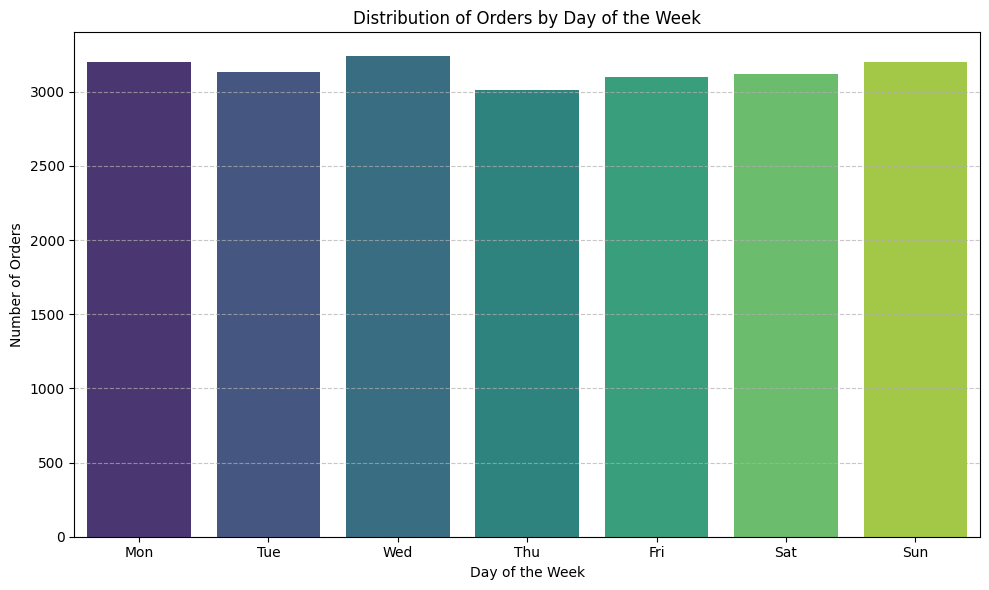

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 計算每個星期幾的訂單數量
order_dow_counts = order_df['order_dow'].value_counts().sort_index()

# 定義星期幾的標籤 (0=週一, 6=週日)
days_of_week = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# 繪製長條圖
plt.figure(figsize=(10, 6))
sns.barplot(
    x=order_dow_counts.index,
    y=order_dow_counts.values,
    palette='viridis')

# 設定X軸標籤為星期幾的名稱
plt.xticks(
    ticks=order_dow_counts.index,
    labels=days_of_week
)

plt.title('Distribution of Orders by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Orders')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 3-3. 小結
- **`loc`** 用標籤／條件選取，**`iloc`** 用整數位置選取。
- 布林篩選用 `&`、`|`，不用 `and`、`or`，每個條件加括號。
- 日期欄位務必先用 `pd.to_datetime()` 轉型，才能用 `.dt` 存取器。

# 4.Profiling

- 先 Profiling 再分析。
- 熟練使用 `head`、`info`、`describe`、`value_counts` 做資料健檢。
- 掌握缺失值處理策略的判斷依據。
- 能進行資料型別轉換與日期/字串處理。

In [ ]:
sessions_df.head()

,session_id,customer_id,session_start,device,traffic_source,campaign,experiment_group
0,1,2473,2025-08-14T11:02,desktop,sem,none,B
1,2,2155,2024-02-29T11:56,mobile,sem,retarget,A
2,3,2437,2024-11-13T16:23,mobile,sem,none,B
3,4,164,2024-04-22T16:15,mobile,email,retarget,B
4,5,1604,2024-06-15T08:39,desktop,direct,none,A


In [ ]:
sessions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   session_id        70000 non-null  int64 
 1   customer_id       70000 non-null  int64 
 2   session_start     70000 non-null  object
 3   device            70000 non-null  object
 4   traffic_source    70000 non-null  object
 5   campaign          70000 non-null  object
 6   experiment_group  70000 non-null  object
dtypes: int64(2), object(5)
memory usage: 3.7+ MB


In [ ]:

sessions_df['date'] = pd.to_datetime(sessions_df['session_start'])
sessions_df["year"] = sessions_df["date"].dt.year      # 年份
sessions_df["month"] = sessions_df["date"].dt.month    # 月份（1~12）
sessions_df["dow"] = sessions_df["date"].dt.dayofweek  # 星期幾（0=週一）
sessions_df["week"] = sessions_df["date"].dt.isocalendar().week  # ISO 週次

In [ ]:
sessions_df.describe()

,session_id,customer_id,date,year,month,dow,week
count,70000.000000,70000.000000,70000,70000.000000,70000.000000,70000.000000,70000.0
mean,35000.500000,1253.009714,2024-12-31 14:59:40.416000256,2024.499471,6.523114,2.995286,26.385057
min,1.000000,1.000000,2024-01-01 00:15:00,2024.000000,1.000000,0.000000,1.0
25%,17500.750000,625.750000,2024-07-01 08:23:00,2024.000000,4.000000,1.000000,13.0
50%,35000.500000,1257.000000,2024-12-31 14:23:00,2024.000000,7.000000,3.000000,26.0
75%,52500.250000,1880.000000,2025-07-03 07:02:15,2025.000000,10.000000,5.000000,39.0
max,70000.000000,2500.000000,2025-12-31 23:52:00,2025.000000,12.000000,6.000000,52.0
std,20207.403759,721.943672,NaN,0.500003,3.450765,1.998866,15.069688


## 4-1.觀察數值分布
* 只對數值欄位有效
* 觀察 min/max 是否異常（例如負數金額）
* 觀察 mean 與 50%（中位數）差距 → 判斷是否偏態



理解常見的資料數值分布名詞：
* **偏態（Skewness）**：平均數與中位數差距大，且分布不對稱。
* **離群值（Outliers）**：極端值遠離其他數據點，可能是錯誤或特殊情況。
* **集中趨勢（Central Tendency）**：數據集中在某個值附近，平均數、中位數、眾數是衡量集中趨勢的指標。
* **平均數（Mean）**：所有數值的總和除以數量，受極端值影響大。
* **中位數（Median）**：將數值排序後的中間值，對偏態分布更穩健。
* **眾數（Mode）**：出現頻率最高的值，適用於類別型資料。


## 4-2.觀察類別分布

In [ ]:
sessions_df['campaign'].value_counts()

,count
campaign,
none,38440
new_user,10379
spring_sale,8401
retarget,7126
double11,5654


In [ ]:
sessions_df["campaign"].value_counts(normalize=True) # 顯示占比

,proportion
campaign,
none,0.549143
new_user,0.148271
spring_sale,0.120014
retarget,0.101800
double11,0.080771


## 4-3.缺失值處理策略
你需要根據**業務情境**做判斷，是否需要補值或刪除

| 策略           | 適用情境                   | 範例                                              |
| -------------- | -------------------------- | ------------------------------------------------- |
| **刪除整列**   | 缺失比例 < 5% 且缺失為隨機 | 少數訂單缺少 customer_id                          |
| **補固定值**   | 缺失有明確業務意義         | campaign 欄空值 → 填 "none"（代表無活動）         |
| **補統計值**   | 數值欄位、缺失比例適中     | 金額欄缺失 → 補中位數（比平均數抗離群值）         |
| **補前/後值**  | 時間序列資料               | 股價缺失 → 用前一天的值                           |
| **標記為類別** | 缺失本身是訊號             | 退貨原因欄空白 → 可能代表「沒填」這件事本身有意義 |
| **保留不處理** | 後續模型可處理缺失         | 某些模型可直接處理 NaN                            |

> **決策流程**：
> 1. 缺失的原因是什麼？（隨機遺漏？系統問題？本來就沒有？）
> 2. 缺失比例多高？（< 5% 通常影響小，> 30% 要特別小心）
> 3. 最後問：填補方式會不會帶入偏誤？
> 4. 是否最終要導入到機器學習模型?


**可以提供資料的健檢報告**

In [ ]:
def column_health_report(df, table_name=""):
    """產出一張表的欄位健康報告。"""
    report = pd.DataFrame({
        "欄位": df.columns,
        "型別": df.dtypes.values,
        "非空數": df.notna().sum().values,
        "缺失數": df.isna().sum().values,
        "缺失率": (df.isna().sum() / len(df) * 100).round(2).values,
        "不重複值": df.nunique().values,
    })
    # 標註風險等級
    report["風險"] = "低"
    report.loc[report["缺失率"] > 10, "風險"] = "中"
    report.loc[report["缺失率"] > 30, "風險"] = "高"

    return report




In [ ]:
print(f"\n=== sessions 欄位健康報告 ===")
display(column_health_report(sessions_df, "sessions"))


=== sessions 欄位健康報告 ===


,欄位,型別,非空數,缺失數,缺失率,不重複值,風險
0,session_id,int64,70000,0,0.0,70000,低
1,customer_id,int64,70000,0,0.0,2500,低
2,session_start,object,70000,0,0.0,67778,低
3,device,object,70000,0,0.0,3,低
4,traffic_source,object,70000,0,0.0,5,低
5,campaign,object,70000,0,0.0,5,低
6,experiment_group,object,70000,0,0.0,2,低
7,date,datetime64[ns],70000,0,0.0,67778,低
8,year,int32,70000,0,0.0,2,低
9,month,int32,70000,0,0.0,12,低


In [ ]:
print("\n=== customers 欄位健康報告 ===")
display(column_health_report(customer_df, "customers"))

print("\n=== products 欄位健康報告 ===")
display(column_health_report(product_df, "products"))

print("\n=== orders 欄位健康報告 ===")
display(column_health_report(order_df, "orders"))

print("\n=== order_items 欄位健康報告 ===")
display(column_health_report(order_item_df, "order_items"))

print("\n=== events 欄位健康報告 ===")
display(column_health_report(events_df, "events"))

print("\n=== ab_assignments 欄位健康報告 ===")
display(column_health_report(ab_df, "ab_assignments"))


=== customers 欄位健康報告 ===


,欄位,型別,非空數,缺失數,缺失率,不重複值,風險
0,customer_id,int64,2500,0,0.0,2500,低
1,signup_date,object,2500,0,0.0,992,低
2,acquisition_channel,object,2500,0,0.0,5,低
3,city,object,2500,0,0.0,6,低
4,segment,object,2500,0,0.0,3,低



=== products 欄位健康報告 ===


,欄位,型別,非空數,缺失數,缺失率,不重複值,風險
0,product_id,int64,60,0,0.0,60,低
1,category,object,60,0,0.0,6,低
2,unit_price,int64,60,0,0.0,60,低



=== orders 欄位健康報告 ===


...

,欄位,型別,非空數,缺失數,缺失率,不重複值,風險
0,order_id,int64,39627,0,0.0,22000,低
1,product_id,int64,39627,0,0.0,60,低
2,quantity,int64,39627,0,0.0,3,低
3,unit_price,int64,39627,0,0.0,60,低
4,discount_rate,float64,39627,0,0.0,5,低



=== events 欄位健康報告 ===


,欄位,型別,非空數,缺失數,缺失率,不重複值,風險
0,event_id,int64,232067,0,0.00,232067,低
1,session_id,int64,232067,0,0.00,70000,低
2,event_type,object,232067,0,0.00,3,低
3,event_time,object,232067,0,0.00,200142,低
4,order_id,float64,8653,223414,96.27,6745,高
5,revenue,float64,232067,0,0.00,4123,低



=== ab_assignments 欄位健康報告 ===


,欄位,型別,非空數,缺失數,缺失率,不重複值,風險
0,customer_id,int64,2500,0,0.0,2500,低
1,experiment_group,object,2500,0,0.0,2,低
2,assign_date,object,2500,0,0.0,16,低


In [ ]:
events_df.head()

,event_id,session_id,event_type,event_time,order_id,revenue
0,1,1,page_view,2025-08-14T11:02,NaN,0.0
1,2,1,page_view,2025-08-14T11:07,NaN,0.0
2,3,2,page_view,2024-02-29T11:56,NaN,0.0
3,4,2,page_view,2024-02-29T12:01,NaN,0.0
4,5,2,page_view,2024-02-29T11:58,NaN,0.0


## 4-4.小結

- 分析前**必做Profiling** 。
- 四步驟：`head` → `info` → `describe` → `value_counts`。
- 缺失值處理需回到**商業問題**判斷，選擇刪除或補值。
- 日期欄位一定要轉 `datetime`
- 金額欄位要確認是數值。

# 5.資料清理

*   統一大小寫
*   檢查空白
*   移除標點符號等等....
*   調整欄位使其更為合理

## 5-1.統一大小寫與子字串操作

In [ ]:
# .str 存取器提供豐富的字串操作: 轉大小寫、是否包含
sessions_df["campaign_clean"] = sessions_df["campaign"].str.strip()    # 去頭尾空白
sessions_df["campaign_upper"] = sessions_df["campaign"].str.upper()    # 轉大寫
sessions_df["is_retarget"] = sessions_df["campaign"].str.contains("retarget")  # 包含判斷

In [ ]:
#  檢查是否有異常類別（例如多餘的空白或拼字錯誤）
print(sessions_df["campaign"].unique())
# ['none' 'spring_sale' 'double11' 'new_user' 'retarget']

['none' 'retarget' 'new_user' 'spring_sale' 'double11']


## 5-2.移除標點符號

In [ ]:
# 假設我們要清除 campaign 欄位中的標點符號 (雖然在這個資料集中可能沒有明顯的標點符號)
# 1. 取得標點符號列表
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [ ]:
# 2. 移除 campaign 欄位中的所有標點符號
sessions_df['campaign_no_punct'] = sessions_df['campaign'].str.replace(r'[!"#$%&\'()*+,-./:;<=>?@[\]^_`{|}~]', '', regex=True)
sessions_df['campaign_no_punct'].head()

,campaign_no_punct
0,none
1,retarget
2,none
3,retarget
4,none


### 5-2-1.詳細範例

In [ ]:
# 假設我們有一個包含標點符號的 Series
data = pd.Series([
    'Hello, world!',
    'This is a test.',
    'Python is fun!!!',
    'No punctuation here'
])

print("Original Series:")
display(data)

# 使用 .str.replace 和正規表達式移除標點符號
# re.escape(string.punctuation) 可以生成所有標點符號的正規表達式
# string.punctuation 包含常見的標點符號，例如 !"#$%&'()*+,-./:;<=>?@[\]^_`{|}~
# 我們需要導入 string 模組來獲取它，但通常直接寫出正規表達式更常見

# 另一種更常見且不依賴 string 模組的方法是直接用 [^\w\s] 來匹配非字母數字和非空白字元
# 或者像下面這樣，明確列出要移除的字符組
cleaned_data = data.str.replace(r'[!"#$%&\'()*+,-./:;<=>?@[\]^_`{|}~]', '', regex=True)

print("Cleaned Series:")
display(cleaned_data)



Original Series:


,0
0,"Hello, world!"
1,This is a test.
2,Python is fun!!!
3,No punctuation here


Cleaned Series:


,0
0,Hello world
1,This is a test
2,Python is fun
3,No punctuation here
